In [222]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from scipy import stats
from sklearn.model_selection import train_test_split

In [223]:
competition_name = "yadro-regression-2025"
download_path = kagglehub.competition_download(competition_name)
print("Файлы сохранены в:", download_path)
print(os.listdir(download_path))

Файлы сохранены в: /Users/nadezdasoroko/.cache/kagglehub/competitions/yadro-regression-2025
['for_prediction.csv', 'train_contest.csv', 'Sample_Submission.csv']


Целевой переменной является значение заработной платы (колонка mean_salary).  
Примечание: в качестве заработной платы обычно указывается некоторый диапазон (от и до). В рассматриваемом файле в качестве значения ЗП (колонка mean_salary) использовано среднее значение такого диапазона.  


train_contest.csv - тренировочный набор данных  
for_prediction.csv - тестовый набор данных  
Sample_Submission.csv - пример файла для отправки (в корректном формате)

# EDA

In [224]:
df = pd.read_csv(f"{download_path}/train_contest.csv")
print(df.shape)
df.head()

(30072, 32)


,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary
0,False,Агент по недвижимости,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Невский...",NaN,NaN,...,[],[],False,"<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",Санкт-Петербург,NaN,125000.0
1,False,IT-специалист/ техник,NaN,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",Иркутская область,NaN,50000.0
2,False,Старший/ведущий инженер-программист,NaN,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...",NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",Ростовская область,NaN,80000.0
3,False,Эксперт / методист приемной комиссии,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': '1-я Миусская ули...",NaN,NaN,...,[],[],False,<p>Департамент информационных технологий РХТУ ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",Москва,NaN,120000.0
4,False,Табельщица/табельщик,NaN,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': 'open', 'name': 'Открытая'}","{'city': None, 'street': None, 'building': Non...",NaN,NaN,...,[],[],False,<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",Саратовская область,NaN,15000.0


In [225]:
df = df.drop_duplicates()

In [226]:
df.describe(include="all").T.iloc[:, :-7]

,count,unique,top,freq
premium,30010,2,False,29909
name,30010,13521,Системный администратор,926
department,751,141,"{'id': 'pochta-4352-office', 'name': '«Почта Р...",106
has_test,30010,2,False,29588
response_letter_required,30010,2,False,29517
area,30010,784,"{'id': '1', 'name': 'Москва', 'url': 'https://...",6188
type,30010,2,"{'id': 'open', 'name': 'Открытая'}",29963
address,19065,12811,"{'city': 'Сочи', 'street': 'микрорайон Централ...",121
response_url,0.0,NaN,NaN,NaN
sort_point_distance,0.0,NaN,NaN,NaN


### Анализ целевой переменной (mean_salary)

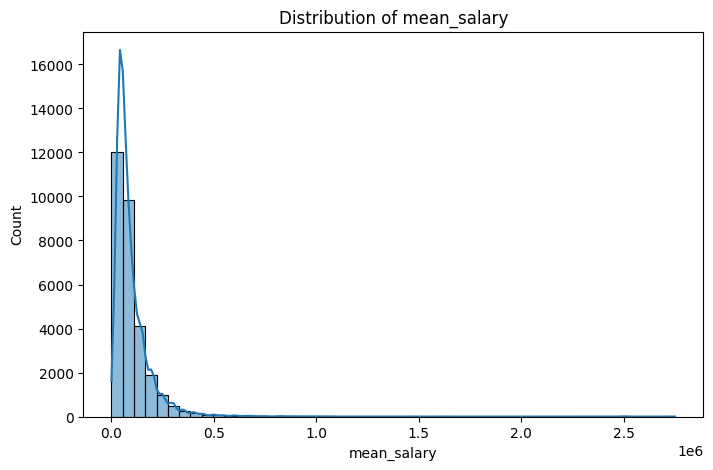

In [227]:
plt.figure(figsize=(8,5))
sns.histplot(df["mean_salary"], bins=50, kde=True)
plt.title("Distribution of mean_salary")
plt.show()

In [228]:
# Асимметрия и эксцесс
skew = stats.skew(df["mean_salary"])
kurt = stats.kurtosis(df["mean_salary"])

print(f"Skewness: {skew}")
print(f"Kurtosis: {kurt}")

Skewness: 7.38201764891423
Kurtosis: 119.51349856142052


Следовательно, в целевой переменной наблюдается правая ассиметрия и тяжелый хвост

MAE  будет страдать от сильных выбросов в mean_salary, т.к. она взвешивает ошибки линейно. 
Можно использовать логарифмическое преобразование для сжатия масштаба, а после предсказания обратно преобразовать.

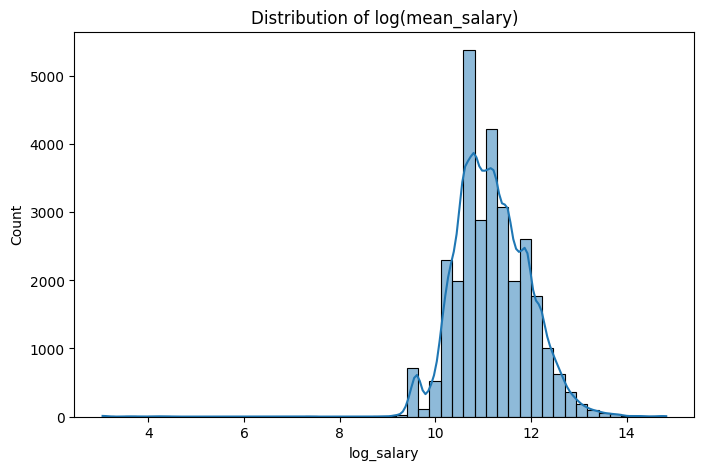

Skew after log: -0.3618077175306792


In [229]:
df["log_salary"] = np.log1p(df["mean_salary"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_salary"], bins=50, kde=True)
plt.title("Distribution of log(mean_salary)")
plt.show()

print("Skew after log:", stats.skew(df["log_salary"]))

Логарифмирование приближает распределение к симметрии. 

In [230]:
Q1 = df["mean_salary"].quantile(0.25)
Q3 = df["mean_salary"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print("Upper bound (IQR method):", upper_bound)
print("Max salary:", df["mean_salary"].max())

Upper bound (IQR method): 236250.0
Max salary: 2750000.0


Обработка выбросов

{'whiskers': [<matplotlib.lines.Line2D at 0x440b400e0>,
 'caps': [<matplotlib.lines.Line2D at 0x440b406b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x440b3fe00>],
 'medians': [<matplotlib.lines.Line2D at 0x440b40ad0>],
 'fliers': [<matplotlib.lines.Line2D at 0x440b40e60>],
 'means': []}

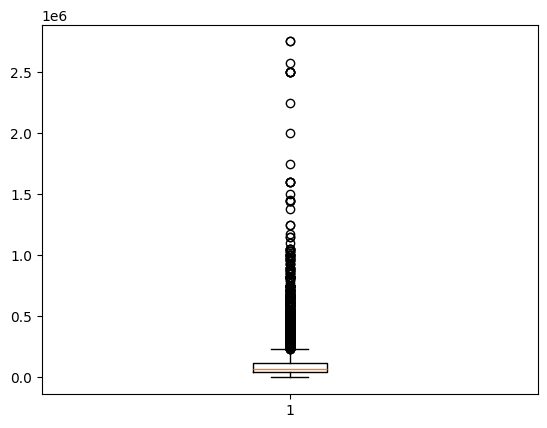

In [231]:
plt.boxplot(df['mean_salary'])

{'whiskers': [<matplotlib.lines.Line2D at 0x440b4f320>,
 'caps': [<matplotlib.lines.Line2D at 0x440b4f890>,
 'boxes': [<matplotlib.lines.Line2D at 0x440b4f020>],
 'medians': [<matplotlib.lines.Line2D at 0x440b4fec0>],
 'fliers': [<matplotlib.lines.Line2D at 0x440b50170>],
 'means': []}

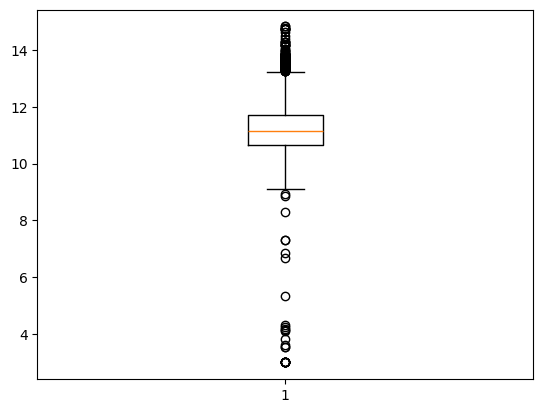

In [232]:
plt.boxplot(df['mean_salary'].apply(lambda x: np.log(x)))

In [233]:
df.loc[df["mean_salary"].eq(df["mean_salary"].max())]

,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary,log_salary
8025,False,Эксперт по элитной недвижимости в Красной Поляне,NaN,False,False,"{'id': '2805', 'name': 'Красная Поляна', 'url'...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],False,<strong>Обязанности:</strong> <ul> <li>Сопрово...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Грамотная речь'}, {'name': 'Ведение...","[{'id': '17.242', 'name': 'Прямые продажи', 'p...",Краснодарский край,NaN,2750000.0,14.827112
27640,False,Эксперт по недвижимости в Красной Поляне,NaN,False,False,"{'id': '2805', 'name': 'Красная Поляна', 'url'...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],False,<strong>Обязанности:</strong> <ul> <li>Сопрово...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Грамотная речь'}, {'name': 'Ведение...","[{'id': '17.242', 'name': 'Прямые продажи', 'p...",Краснодарский край,NaN,2750000.0,14.827112


Логарифм применим позже.  
Ограничение по диапазону зарплат ухудшает результат. 

## Анализ пропусков

In [234]:
df.replace('[]', np.nan, inplace=True)
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/2310603955.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('[]', np.nan, inplace=True)


relations                 1.000000
immediate_redirect_url    1.000000
response_url              1.000000
sort_point_distance       1.000000
insider_interview         0.996868
working_days              0.993369
working_time_modes        0.980573
department                0.974975
working_time_intervals    0.965645
contacts                  0.365012
address                   0.364712
key_skills                0.173309
dtype: float64

Удалим колонки, которые не заполнены более чем на 90%

In [235]:
list_to_drop = list(missing[missing > 0.9].index)
df.drop(list_to_drop, axis=1, inplace=True)

Можно удалить еще следующие колонки, потому что больше 90% заполнены только False

In [236]:
lst_to_drop = []
for col in df.columns:
  if df[col].dtype =='bool':
    print(df[col].value_counts(normalize=True)*100)
    print()
    lst_to_drop.append(col)

premium
False    99.663446
True      0.336554
Name: proportion, dtype: float64

has_test
False    98.593802
True      1.406198
Name: proportion, dtype: float64

response_letter_required
False    98.357214
True      1.642786
Name: proportion, dtype: float64

archived
False    99.986671
True      0.013329
Name: proportion, dtype: float64

accept_temporary
False    90.639787
True      9.360213
Name: proportion, dtype: float64



In [237]:
df.drop(lst_to_drop, axis=1, inplace=True)

## Анализ категориальных признаков

Удалим все колонки с ссылками

In [238]:
url_lst = [x for x in df.columns if 'url' in x]
df.drop(url_lst, axis=1, inplace=True)

Контакты не важны

In [239]:
df.drop('contacts', axis=1, inplace=True)

Все вакансии опубликованы в 2022, поэтому считаем, что сильной зависимости от дат нет. Удалим столбцы published_at и created_at

In [240]:
df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")
df['published_at'].value_counts()

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/2260017115.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['published_at'] = pd.to_datetime(df['published_at']).dt.to_period("Y")


published_at
2022    30010
Freq: Y-DEC, Name: count, dtype: int64

In [241]:
df.drop(['created_at', 'published_at'], axis=1, inplace=True)

Удаление, потому что пока не знаем, что с ними делать

In [242]:
df.drop(['employer', 'snippet', 'description', 'specializations'], axis=1, inplace=True)

Соберем все в одну функцию

In [243]:
def func1(df):
  df.replace('[]', np.nan, inplace=True)
  columns_to_drop = ['response_url', 'sort_point_distance', 'immediate_redirect_url', 'insider_interview', 'department']
  df.drop([col for col in columns_to_drop if col in df.columns], axis=1, inplace=True)
  df.drop(lst_to_drop, axis=1, inplace=True)
  df.drop(url_lst, axis=1, inplace=True)
  df.drop('contacts', axis=1, inplace=True)
  df.drop(['created_at', 'published_at'], axis=1, inplace=True)
  df.drop(['employer', 'snippet', 'description', 'specializations'], axis=1, inplace=True)

## Feature engineering

### 2. Обработка местоположения

In [244]:
df.loc[0, 'area']

"{'id': '2', 'name': 'Санкт-Петербург', 'url': 'https://api.hh.ru/areas/2'}"

По идее, это из таблицы городов и отсюда нужно только название, поэтому остальное удаляем.

In [245]:
import json

def extract_city(area_str):
    try:
        area_dict = json.loads(area_str.replace("'", '"'))  # заменяем одинарные кавычки на двойные для корректного JSON
        return area_dict.get('name')
    except:
        return None

# Применяем функцию
df['area'] = df['area'].apply(extract_city)
# df['area']

In [246]:
df['area'].value_counts()

area
Москва                                6188
Санкт-Петербург                       2893
Екатеринбург                          1056
Новосибирск                            951
Краснодар                              892
                                      ... 
Артемовский (Свердловская область)       1
Торжок                                   1
Кимовск                                  1
Путилково                                1
Тура (Красноярский край)                 1
Name: count, Length: 784, dtype: int64

Слишком много городов, оставим названия только самым крупным, а остальные разделим на категории по кол-ву вакансий

In [247]:
city_counts = df['area'].value_counts()

def categorize_city(city, city_counts):
    if city_counts.get(city, 0) > 1000:  # Крупные города
        return city
    elif city_counts.get(city, 0) > 100:   # Средние города
        return 'Средний город'
    else:                                  # Малые города
        return 'Маленький город'

df['city'] = df['area'].apply(lambda x: categorize_city(x, city_counts))
df.drop(['area', 'region'], axis=1, inplace=True)
df['city'].value_counts()

city
Средний город      14107
Москва              6188
Маленький город     5766
Санкт-Петербург     2893
Екатеринбург        1056
Name: count, dtype: int64

Вряд ли адрес сильно влияет на зарплату, можно остановиться на городе, а адреса удалить

In [248]:
df.drop('address', axis=1, inplace=True)

Вместо городов будем сравнивать средние зарплаты по этому типу города

In [249]:
city_mean_salary = df.groupby('city')['mean_salary'].mean('mean_salary').reset_index()
city_mean_salary = city_mean_salary.rename(columns={'mean_salary': 'city_mean_salary'})
df = df.merge(city_mean_salary, how='left', on='city')
df[['city', 'city_mean_salary']]

,city,city_mean_salary
0,Санкт-Петербург,114138.685620
1,Маленький город,68126.674211
2,Средний город,90407.504537
3,Москва,134621.210811
4,Маленький город,68126.674211
...,...,...
30005,Москва,134621.210811
30006,Средний город,90407.504537
30007,Маленький город,68126.674211
30008,Екатеринбург,93230.418087


In [250]:
df.drop('city', axis=1, inplace=True)

Соберем все в одну функцию

In [251]:
def func2(df, city_mean_salary):
    df['area'] = df['area'].apply(extract_city)
    city_counts = df['area'].value_counts()
    df['city'] = df['area'].apply(lambda x: categorize_city(x, city_counts))
    df.drop(['area', 'region'], axis=1, inplace=True)

    df.drop('address', axis=1, inplace=True)

    df = df.merge(city_mean_salary, how='left', on='city')
    df.drop('city', axis=1, inplace=True)
    return df


### 3. Выделение нужного в JSON-массивах. Обработка колонок 'type', 'schedule', 'experience'.

Для оставшихся колонок в виде JSON-массивов с небольшим количеством категорий выделим нужную информацию и получим колонки с категориальными признаками. 

In [252]:
import json
df['type'] = df['type'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
df['type'].value_counts()

type
Открытая     29963
Анонимная       47
Name: count, dtype: int64

In [253]:
df['is_open'] = df['type'].replace({"Открытая" : 1, "Анонимная" : 0}).astype(int)
df.drop('type', axis = 1, inplace = True)

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/1747803942.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_open'] = df['type'].replace({"Открытая" : 1, "Анонимная" : 0}).astype(int)


In [254]:
df['schedule'] = df['schedule'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
df['schedule'].value_counts()

schedule
Полный день         22668
Удаленная работа     4550
Гибкий график        1939
Сменный график        759
Вахтовый метод         94
Name: count, dtype: int64

In [255]:
df['experience'] = df['experience'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
df['experience'].value_counts()

experience
От 1 года до 3 лет    14729
Нет опыта              8359
От 3 до 6 лет          6263
Более 6 лет             659
Name: count, dtype: int64

Опыт можно четко расставить по шкале, поэтому заменим название категории на ее ранг. 

In [256]:
df['experience'].replace({"Нет опыта" : 0, "От 1 года до 3 лет" : 1, "От 3 до 6 лет" : 2, "Более 6 лет" : 3}, inplace=True)

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/592014202.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['experience'].replace({"Нет опыта" : 0, "От 1 года до 3 лет" : 1, "От 3 до 6 лет" : 2, "Более 6 лет" : 3}, inplace=True)
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/592014202.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the f

Из employer оставим только name

In [257]:
import ast
# df['employer'] = df['employer'].apply(lambda x: ast.literal_eval(x)['name'])

Соберем все в одну функцию

In [258]:
def func3(df):
    df['type'] = df['type'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
    df['is_open'] = df['type'].replace({"Открытая" : 1, "Анонимная" : 0, "Рекламная" : 1}).astype(int)
    df.drop('type', axis = 1, inplace = True)

    df['schedule'] = df['schedule'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
    
    df['experience'] = df['experience'].apply(lambda x: json.loads(x.replace("'", '"')).get('name'))
    df['experience'].replace({"Нет опыта" : 0, "От 1 года до 3 лет" : 1, "От 3 до 6 лет" : 2, "Более 6 лет" : 3}, inplace=True)

### 4. Обработка name с помощью эмбеддингов

Для получения векторных представлений (эмбеддингов) текстовых полей 'name' и 'employer' используем модель all-MiniLM-L6-v2.

In [259]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

In [260]:
embeddings_name = model.encode(df['name'].str.lower().replace(r'[\W_]+', ' ', regex=True).tolist()) # Приводим к нижнему регистру, заменяем небуквенно-цифровые символы на пробелы, преобразуем в список строк
print(embeddings_name.shape)

KeyboardInterrupt: 

In [ ]:
for i in range(embeddings_name.shape[1]):
    df[f'name_emb_{i}'] = embeddings_name[:, i]

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/3509905909.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'name_emb_{i}'] = embeddings_name[:, i]
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/3509905909.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'name_emb_{i}'] = embeddings_name[:, i]
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/3509905909.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

In [ ]:
def func4(df):
    embeddings_name = model.encode(df['name'].str.lower().replace(r'[\W_]+', ' ', regex=True).tolist()) # Приводим к нижнему регистру, заменяем небуквенно-цифровые символы на пробелы, преобразуем в список строк
    for i in range(embeddings_name.shape[1]):
        df[f'name_emb_{i}'] = embeddings_name[:, i]

### 5. Обработка key_skills

Попробую из key_skills составить массив навыков

In [ ]:
def extract_key_skills(key_skills_list):
  if key_skills_list is np.nan:
    return np.nan
  else:
    return [d['name'] for d in ast.literal_eval(key_skills_list)]

df['key_skills'] = df['key_skills'].apply(lambda x: extract_key_skills(x))

In [ ]:
df['is_developer'] = df['name'].str.contains('программ|разраб|developer|dev', case=False)
df['is_data_analyst'] = df['name'].str.contains('data|scientist|analytics|аналитик|анализ|данн', case=False)
df['is_rieltor'] = df['name'].str.contains('риелтор|недвижимост|продаж', case=False)
df['is_lead'] = df['name'].str.contains('начальник|lead', case=False)
df['is_senior'] = df['name'].str.contains('ведущий|руководитель|senior|старший', case=False)

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/1126687300.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_developer'] = df['name'].str.contains('программ|разраб|developer|dev', case=False)
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/1126687300.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_data_analyst'] = df['name'].str.contains('data|scientist|analytics|аналитик|анализ|данн', case=False)
/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/1126687300.py:3: 

In [ ]:
df.drop(['key_skills', 'name'], axis=1, inplace=True)

In [ ]:
def func5(df):
    df['key_skills'] = df['key_skills'].apply(lambda x: extract_key_skills(x))
    
    df['is_developer'] = df['name'].str.contains('программ|разраб|developer|dev', case=False)
    df['is_data_analyst'] = df['name'].str.contains('data|scientist|analytics|аналитик|анализ|данн', case=False)
    df['is_rieltor'] = df['name'].str.contains('риелтор|недвижимост|продаж', case=False)
    df['is_lead'] = df['name'].str.contains('начальник|lead', case=False)
    df['is_senior'] = df['name'].str.contains('ведущий|руководитель|senior|старший', case=False)

    df.drop(['key_skills', 'name'], axis=1, inplace=True)

### 6. Обработка графика работы

In [ ]:
df['working_time_intervals'].value_counts()

working_time_intervals
[{'id': 'from_four_to_six_hours_in_a_day', 'name': 'Можно работать сменами по\xa04–6 часов в\xa0день'}]    1031
Name: count, dtype: int64

In [ ]:
flt = df['working_time_intervals'].isna()
df['work_in_shifts'] = 1
df.loc[flt, 'work_in_shifts'] = 0
df['work_in_shifts'].value_counts()

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/102410571.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['work_in_shifts'] = 1


work_in_shifts
0    28979
1     1031
Name: count, dtype: int64

In [ ]:
df['working_days'].value_counts()

working_days
[{'id': 'only_saturday_and_sunday', 'name': 'Работа только по\xa0сб\xa0и\xa0вс'}]    199
Name: count, dtype: int64

In [ ]:
flt = df['working_days'].isna()
df['weekend_work'] = 1
df.loc[flt, 'weekend_work'] = 0
df['weekend_work'].value_counts()

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/2242295359.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['weekend_work'] = 1


weekend_work
0    29811
1      199
Name: count, dtype: int64

In [ ]:
df['working_time_modes'].value_counts()

working_time_modes
[{'id': 'start_after_sixteen', 'name': 'Можно начинать работать после 16:00'}]    583
Name: count, dtype: int64

In [ ]:
flt = df['working_time_modes'].isna()
df['Delayed_start_of_work'] = 1
df.loc[flt, 'Delayed_start_of_work'] = 0
df['Delayed_start_of_work'].value_counts()

/var/folders/3z/h7_y2tw90bd9_d3j8sfghz_00000gn/T/ipykernel_3573/1820470644.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Delayed_start_of_work'] = 1


Delayed_start_of_work
0    29427
1      583
Name: count, dtype: int64

In [ ]:
df.drop(['working_time_modes', 'working_days', 'working_time_intervals'], axis=1, inplace=True)

In [ ]:
def func6(df):
    flt = df['working_time_intervals'].isna()
    df['work_in_shifts'] = 1
    df.loc[flt, 'work_in_shifts'] = 0

    flt = df['working_days'].isna()
    df['weekend_work'] = 1
    df.loc[flt, 'weekend_work'] = 0

    flt = df['working_time_modes'].isna()
    df['Delayed_start_of_work'] = 1
    df.loc[flt, 'Delayed_start_of_work'] = 0

    df.drop(['working_time_modes', 'working_days', 'working_time_intervals'], axis=1, inplace=True)

In [ ]:
df

,schedule,experience,mean_salary,log_salary,city_mean_salary,is_open,name_emb_0,name_emb_1,name_emb_2,name_emb_3,...,name_emb_382,name_emb_383,is_developer,is_data_analyst,is_rieltor,is_lead,is_senior,work_in_shifts,weekend_work,Delayed_start_of_work
0,Гибкий график,0,125000.0,11.736077,114138.685620,1,-0.021850,0.048913,-0.037609,0.032939,...,-0.001026,-0.043442,False,False,True,False,False,0,0,0
1,Вахтовый метод,1,50000.0,10.819798,68126.674211,1,-0.004469,0.056483,-0.078017,0.017163,...,0.069578,-0.016295,False,False,False,False,False,0,0,0
2,Полный день,1,80000.0,11.289794,90407.504537,1,0.056179,0.050399,-0.079194,0.019477,...,-0.008554,0.013429,True,False,False,False,True,0,0,0
3,Полный день,1,120000.0,11.695255,134621.210811,1,0.041678,0.030779,-0.058289,0.001207,...,0.017558,0.029135,False,False,False,False,False,0,0,0
4,Полный день,1,15000.0,9.615872,68126.674211,1,0.065373,0.053399,-0.009875,0.037846,...,0.014314,-0.107286,False,False,False,False,False,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30005,Полный день,3,190000.0,12.154785,134621.210811,1,0.004341,0.035626,0.006119,0.020234,...,-0.043264,-0.028992,False,False,False,False,True,0,0,0
30006,Полный день,1,45000.0,10.714440,90407.504537,1,-0.034910,0.015615,-0.097355,-0.006434,...,0.007711,-0.059532,False,False,False,False,False,0,0,0
30007,Полный день,1,75000.0,11.225257,68126.674211,1,0.014121,0.022522,-0.047916,-0.009346,...,0.011274,0.005799,True,False,False,False,False,0,0,0
30008,Гибкий график,1,30000.0,10.308986,93230.418087,1,0.042497,0.072015,-0.000499,-0.022446,...,0.061221,0.015146,False,False,False,False,False,1,0,0


### 7. One-hot кодирование для категориальных признаков schedule

Далее преобразовываем категориальные признаки.

In [ ]:
schedule_categories = ['schedule_' + x for x in df['schedule'].unique()]

In [ ]:
schedule_dummies = pd.get_dummies(df['schedule'], prefix='schedule')
df = pd.concat([df, schedule_dummies], axis=1)
df.drop('schedule', axis=1, inplace=True)

In [ ]:
def func7(df, schedule_cats=None):

    # Для schedule
    schedule_dummies = pd.get_dummies(df['schedule'], prefix='schedule')
    if schedule_cats is not None:
        # Добавляем отсутствующие колонки
        for cat in schedule_cats:
            col_name = f'schedule_{cat}'
            if col_name not in schedule_dummies.columns:
                schedule_dummies[col_name] = 0
        # # Упорядочиваем колонки
        # schedule_dummies = schedule_dummies.reindex(columns=[f'schedule_{cat}' for cat in schedule_cats], fill_value=0)
    
    df = pd.concat([df, schedule_dummies], axis=1)
    df.drop('schedule', axis=1, inplace=True)


In [ ]:
df

,experience,mean_salary,log_salary,city_mean_salary,is_open,name_emb_0,name_emb_1,name_emb_2,name_emb_3,name_emb_4,...,is_lead,is_senior,work_in_shifts,weekend_work,Delayed_start_of_work,schedule_Вахтовый метод,schedule_Гибкий график,schedule_Полный день,schedule_Сменный график,schedule_Удаленная работа
0,0,125000.0,11.736077,114138.685620,1,-0.021850,0.048913,-0.037609,0.032939,-0.117632,...,False,False,0,0,0,False,True,False,False,False
1,1,50000.0,10.819798,68126.674211,1,-0.004469,0.056483,-0.078017,0.017163,-0.052432,...,False,False,0,0,0,True,False,False,False,False
2,1,80000.0,11.289794,90407.504537,1,0.056179,0.050399,-0.079194,0.019477,-0.096014,...,False,True,0,0,0,False,False,True,False,False
3,1,120000.0,11.695255,134621.210811,1,0.041678,0.030779,-0.058289,0.001207,-0.062299,...,False,False,0,0,0,False,False,True,False,False
4,1,15000.0,9.615872,68126.674211,1,0.065373,0.053399,-0.009875,0.037846,-0.040770,...,False,False,0,0,0,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30005,3,190000.0,12.154785,134621.210811,1,0.004341,0.035626,0.006119,0.020234,-0.051673,...,False,True,0,0,0,False,False,True,False,False
30006,1,45000.0,10.714440,90407.504537,1,-0.034910,0.015615,-0.097355,-0.006434,-0.025500,...,False,False,0,0,0,False,False,True,False,False
30007,1,75000.0,11.225257,68126.674211,1,0.014121,0.022522,-0.047916,-0.009346,-0.110898,...,False,False,0,0,0,False,False,True,False,False
30008,1,30000.0,10.308986,93230.418087,1,0.042497,0.072015,-0.000499,-0.022446,-0.011575,...,False,False,1,0,0,False,True,False,False,False


## Анализ целевой переменной mean_salary

MAE  будет страдать от сильных выбросов в mean_salary, т.к. она взвешивает ошибки линейно. 
Можно использовать логарифмическое преобразование для сжатия масштаба, а после предсказания обратно преобразовать.

{'whiskers': [<matplotlib.lines.Line2D at 0x420f11a60>,
 'caps': [<matplotlib.lines.Line2D at 0x420f10da0>,
 'boxes': [<matplotlib.lines.Line2D at 0x420f126c0>],
 'medians': [<matplotlib.lines.Line2D at 0x420f114c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x420f11730>],
 'means': []}

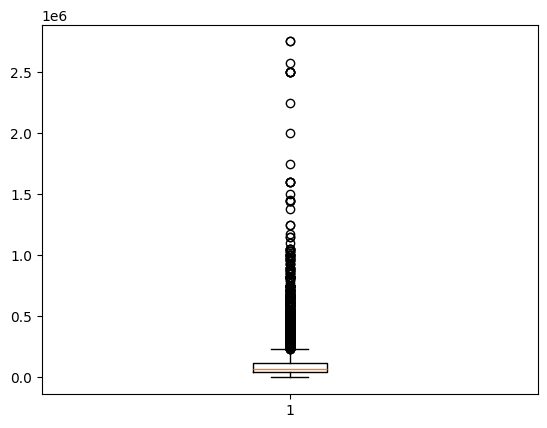

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.boxplot(df['mean_salary'])

{'whiskers': [<matplotlib.lines.Line2D at 0x34c758ec0>,
 'caps': [<matplotlib.lines.Line2D at 0x34c75b200>,
 'boxes': [<matplotlib.lines.Line2D at 0x34c758650>],
 'medians': [<matplotlib.lines.Line2D at 0x34c759610>],
 'fliers': [<matplotlib.lines.Line2D at 0x34c759280>],
 'means': []}

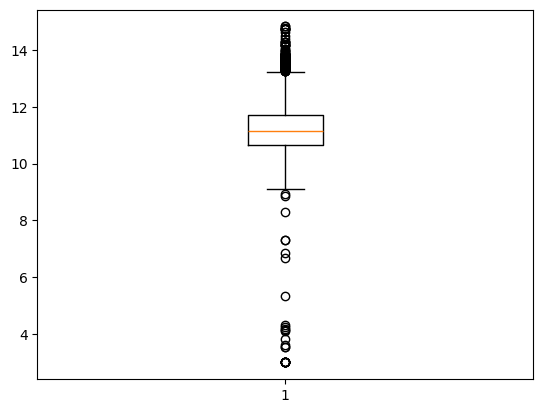

In [ ]:
plt.boxplot(df['mean_salary'].apply(lambda x: np.log(x)))

Логарифм применим позже.  
Ограничение по диапазону зарплат ухудшает результат. 

# Аналогичная обработка тестового набора данных

In [ ]:
df_pred = pd.read_csv(path + "/for_prediction.csv")

NameError: name 'path' is not defined

In [ ]:
%%capture
func1(df_pred)
df_pred = func2(df_pred, city_mean_salary)
func3(df_pred)
func4(df_pred)
func5(df_pred)
func6(df_pred)
func7(df_pred, schedule_categories)

In [ ]:
# Проверка, что колонки совпадают с тренировочным набором
# Добавление отсутствующих колонок
train_cols = set(df.drop('mean_salary', axis=1).columns)
test_cols = set(df_pred.drop('Id', axis=1).columns)

for col in train_cols - test_cols:
    df_pred[col] = 0
    print(col)

for col in test_cols - train_cols:
    if col != 'Id':
        df_pred.drop(col, axis=1, inplace=True)

# Упорядочивание колонок как в тренировочном наборе
train_cols_order = df.drop('mean_salary', axis=1).columns.tolist()
df_pred = df_pred[['Id'] + train_cols_order]

schedule_Вахтовый метод
schedule_Удаленная работа
schedule_Гибкий график
schedule_Сменный график
schedule_Полный день


In [ ]:
df_pred

,Id,experience,city_mean_salary,is_open,name_emb_0,name_emb_1,name_emb_2,name_emb_3,name_emb_4,name_emb_5,...,is_lead,is_senior,work_in_shifts,weekend_work,Delayed_start_of_work,schedule_Вахтовый метод,schedule_Гибкий график,schedule_Полный день,schedule_Сменный график,schedule_Удаленная работа
0,0,1,134738.590843,1,0.034244,0.078160,-0.009737,0.018762,-0.058454,0.006389,...,False,False,0,0,0,0,0,0,0,0
1,1,0,90404.228668,1,0.016195,0.056814,0.026840,-0.015345,-0.054286,0.021636,...,False,False,0,0,0,0,0,0,0,0
2,2,0,90404.228668,1,0.001676,0.054740,0.028216,-0.000011,-0.033859,-0.020591,...,False,False,0,0,0,0,0,0,0,0
3,3,2,90404.228668,1,0.009665,0.012533,-0.002277,-0.061712,-0.113764,-0.011051,...,False,False,0,0,0,0,0,0,0,0
4,4,1,134738.590843,1,0.025050,0.080505,-0.087802,0.027451,-0.065855,-0.001304,...,False,True,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7513,7513,1,68132.201058,1,-0.046323,0.133809,-0.030998,0.013514,-0.053348,0.069178,...,False,False,0,0,0,0,0,0,0,0
7514,7514,1,134738.590843,1,-0.025338,0.098874,-0.027814,0.061213,-0.006586,0.038891,...,False,True,0,0,0,0,0,0,0,0
7515,7515,0,90404.228668,1,0.017880,0.061173,-0.081873,0.043477,-0.053118,0.078479,...,False,False,0,0,0,0,0,0,0,0
7516,7516,1,68132.201058,1,-0.005541,0.017839,-0.023107,-0.008329,-0.101785,0.012020,...,False,True,0,0,0,0,0,0,0,0


# ML

## Базовая модель: линейная регрессия

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(['mean_salary'], axis=1), df['mean_salary'], test_size=0.2, random_state=42)

In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test) 

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error

base_reg = LinearRegression().fit(X_train, y_train_log)
print('MAE score: ', mean_absolute_error(y_test_log, base_reg.predict(X_test)))

MAE score:  0.3719078897561151


In [ ]:
prediction_log = base_reg.predict(df_pred.drop('Id', axis=1))
prediction = np.expm1(prediction_log) 
submission = pd.DataFrame({
    'Id': df_pred['Id'],
    'Predicted': prediction
})

submission.to_csv('submission.csv', index=False)

## XGBRegressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# parameters = {
#     'n_estimators': [50, 100],
#     'max_depth': [3, 4, 5],
#     'learning_rate': [0.01, 0.1],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 1.0],
#     'gamma': [0, 0.1, 0.2]
# }

# XGBR = XGBRegressor(random_state=42)

# grid_search = GridSearchCV(
#     estimator=XGBR,
#     param_grid=parameters,
#     scoring='neg_mean_absolute_error',
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )
# grid_search.fit(X_train, y_train)

# print(f"Лучшие параметры: {grid_search.best_params_}")

In [ ]:
XGBR = XGBRegressor(random_state=42, colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=100, subsample=0.8).fit(X_train, y_train_log)
print('MAE score: ', mean_absolute_error(y_test_log, XGBR.predict(X_test)))

MAE score:  0.3289982729390123


In [ ]:
prediction_log = XGBR.predict(df_pred.drop('Id', axis=1))
prediction = np.expm1(prediction_log) 
submission = pd.DataFrame({
    'Id': df_pred['Id'],
    'Predicted': prediction
})

submission.to_csv('submission_XGBR.csv', index=False)

Дальнейшие идеи:
- разбить published_at и created_at по месяцам/кварталам, а не удалять
- попробовать убрать is_open, слишком не сбалансирован, вряд ли влияет на результат
- Подумать, как обработать employer
- Надо теперь подумать как заполнять пропуски в key_skills, достовать как-то инфу из других текстовых колонок snippet, description, specialization
- Пункт 7 - это One-hot кодирование? Если нет, то попробовать его

# A/B-эксперимент